In [51]:
import numpy as np
import matplotlib.pyplot as plt
PMNS = np.load('PMNS.npy')

In [52]:
# Assumes 3 neutrinos, normal ordering, without SK-atm
delta21 = np.array([7.39e-5, 0.21e-5]) # ev^2
delta32 = np.array([2.449e-3, 0.032e-3]) # ev^2
delta31 = delta21 + delta32

In [53]:
"""
Calculate the oscillation probability of neutrinos.

Parameters:
E : [float, float]
    Neutrino energy and its uncertainty in GeV.
L : [float, float]
    Baseline distance and its uncertainty in km.
alpha : int
    Initial neutrino flavor index (0: electron, 1: muon, 2: tau).
beta : int
    Final neutrino flavor index (0: electron, 1: muon, 2: tau).

Returns:
float
    Oscillation probability from flavor alpha to beta.
"""
def oscillationProbability(alpha, beta, L, E):
    prob = 0
    if alpha == beta:
        prob += 1
    prob -= 4*PMNS[alpha,0,0]*PMNS[beta,0,0]*PMNS[alpha,1,0]*PMNS[beta,1,0]*(np.sin(1.267*delta21[0]*L[0]/E[0])**2)
    prob -= 4*PMNS[alpha,0,0]*PMNS[beta,0,0]*PMNS[alpha,2,0]*PMNS[beta,2,0]*(np.sin(1.267*delta31[0]*L[0]/E[0])**2)
    prob -= 4*PMNS[alpha,1,0]*PMNS[beta,1,0]*PMNS[alpha,2,0]*PMNS[beta,2,0]*(np.sin(1.267*delta32[0]*L[0]/E[0])**2)
    partialD21 = -8*PMNS[alpha,0,0]*PMNS[beta,0,0]*PMNS[alpha,1,0]*PMNS[beta,1,0]\
                *1.267*L[0]*np.sin(1.267*delta21[0]*L[0]/E[0])*np.cos(1.267*delta21[0]*L[0]/E[0])/E[0]
    partialD31 = -8*PMNS[alpha,0,0]*PMNS[beta,0,0]*PMNS[alpha,2,0]*PMNS[beta,2,0]\
                *1.267*L[0]*np.sin(1.267*delta31[0]*L[0]/E[0])*np.cos(1.267*delta31[0]*L[0]/E[0])/E[0]
    partialD32 = -8*PMNS[alpha,1,0]*PMNS[beta,1,0]*PMNS[alpha,2,0]*PMNS[beta,2,0]\
                *1.267*L[0]*np.sin(1.267*delta32[0]*L[0]/E[0])*np.cos(1.267*delta32[0]*L[0]/E[0])/E[0]
    partialL = -8*(PMNS[alpha,0,0]*PMNS[beta,0,0]*PMNS[alpha,1,0]*PMNS[beta,1,0]\
                *1.267*delta21[0]*np.sin(1.267*delta21[0]*L[0]/E[0])*np.cos(1.267*delta21[0]*L[0]/E[0])/E[0]\
                +PMNS[alpha,0,0]*PMNS[beta,0,0]*PMNS[alpha,2,0]*PMNS[beta,2,0]\
                *1.267*delta31[0]*np.sin(1.267*delta31[0]*L[0]/E[0])*np.cos(1.267*delta31[0]*L[0]/E[0])/E[0]\
                +PMNS[alpha,1,0]*PMNS[beta,1,0]*PMNS[alpha,2,0]*PMNS[beta,2,0]\
                *1.267*delta32[0]*np.sin(1.267*delta32[0]*L[0]/E[0])*np.cos(1.267*delta32[0]*L[0]/E[0])/E[0])
    partialE = 8*(PMNS[alpha,0,0]*PMNS[beta,0,0]*PMNS[alpha,1,0]*PMNS[beta,1,0]\
                *1.267*delta21[0]*L[0]*np.sin(1.267*delta21[0]*L[0]/E[0])*np.cos(1.267*delta21[0]*L[0]/E[0])/(E[0]**2)\
                +PMNS[alpha,0,0]*PMNS[beta,0,0]*PMNS[alpha,2,0]*PMNS[beta,2,0]\
                *1.267*delta31[0]*L[0]*np.sin(1.267*delta31[0]*L[0]/E[0])*np.cos(1.267*delta31[0]*L[0]/E[0])/(E[0]**2)\
                +PMNS[alpha,1,0]*PMNS[beta,1,0]*PMNS[alpha,2,0]*PMNS[beta,2,0]\
                *1.267*delta32[0]*L[0]*np.sin(1.267*delta32[0]*L[0]/E[0])*np.cos(1.267*delta32[0]*L[0]/E[0])/(E[0]**2))
    probUnc = np.sqrt((partialD21*delta21[1])**2 + (partialD31*delta31[1])**2 + (partialD32*delta32[1])**2 \
                     + (partialL*L[1])**2 + (partialE*E[1])**2)
    return np.array([prob, probUnc])

In [54]:
testEng = np.array([5,0]) # GeV
testL = np.array([1300,0]) # km
print("              e                  mu                 tau")
print("e  ", oscillationProbability(0,0,testL,testEng)[0], oscillationProbability(0,1,testL,testEng)[0], oscillationProbability(0,2,testL,testEng)[0])
print("mu ", oscillationProbability(1,0,testL,testEng)[0], oscillationProbability(1,1,testL,testEng)[0], oscillationProbability(1,2,testL,testEng)[0])
print("tau", oscillationProbability(2,0,testL,testEng)[0], oscillationProbability(2,1,testL,testEng)[0], oscillationProbability(2,2,testL,testEng)[0])

print("              e                  mu                 tau")
print("e  ", oscillationProbability(0,0,testL,testEng)[1], oscillationProbability(0,1,testL,testEng)[1], oscillationProbability(0,2,testL,testEng)[1])
print("mu ", oscillationProbability(1,0,testL,testEng)[1], oscillationProbability(1,1,testL,testEng)[1], oscillationProbability(1,2,testL,testEng)[1])
print("tau", oscillationProbability(2,0,testL,testEng)[1], oscillationProbability(2,1,testL,testEng)[1], oscillationProbability(2,2,testL,testEng)[1])

              e                  mu                 tau
e   0.9523555922291325 0.029799057888152916 0.01784534988271455
mu  0.029799057888152902 0.4713955242160053 0.49880541789584165
tau 0.017845349882714558 0.49880541789584165 0.4833492322214437
              e                  mu                 tau
e   0.0007351181729202824 0.0022623795640477704 0.001957210943650477
mu  0.0022623795640477704 0.007606074149957416 0.007561184180836847
tau 0.001957210943650477 0.007561184180836847 0.008593504620921491


In [55]:
# Values needed for analysis in https://arxiv.org/pdf/hep-ex/0111033
mPi = np.array([139.57061e-3, 0.00024e-3]) # Mass of charged pion and uncertainty in GeV
mMu = np.array([105.6583668e-3, 0.0000038e-3]) # Mass of muon and uncertainty in GeV
eNuStarUnc = np.sqrt(((mPi[0]**2 - mMu[0]**2) / (2*mPi[0]**2) )**2 * mPi[1]**2 + ( mMu[0]/mPi[0] )**2 * mMu[1]**2)
eNuStar = np.array([(mPi[0]**2 - mMu[0]**2) / (2*mPi[0]), eNuStarUnc]) # Energy of neutrino in pion rest frame in GeV

def cosAngle(nuAng, nuEng):
    """
    Calculate the cosine of the angle between the neutrino direction and the pion direction in the pion rest frame.
    
    Parameters:
    nuAng: [float, float]
        Off-axis angle of the neutrino and its uncertainty in degrees.
    nuEng: [float, float]
        Energy of the neutrino and its uncertainty in GeV.

    Returns:
    [float, float]
        Cosine of thetaStar and its uncertainty.
    """
    nuAng = nuAng * (np.pi/180) # Convert to radians
    ret = np.sqrt(1-(nuEng[0]**2/eNuStar[0]**2)*(1/(np.cos(nuAng[0])**2)-1))
    partialNuEng = -(nuEng[0]/(eNuStar[0]**2)) * (1/(np.cos(nuAng[0])**2)-1) / ret
    partialEStar = (nuEng[0]**2)/(eNuStar[0]**3) * (1/(np.cos(nuAng[0])**2)-1) / ret
    partialNuAng = -(nuEng[0]**2)/(eNuStar[0]**2) * (np.sin(nuAng[0])/(np.cos(nuAng[0])**3)) / ret
    retUnc = np.sqrt(partialNuEng**2 * nuEng[1]**2 + partialEStar**2 * eNuStar[1]**2 + partialNuAng**2 * nuAng[1]**2)
    return np.array([ret, retUnc])

def pionEnergy(nuAng, nuEng):
    """
    Calculate the energy of the pion given the neutrino off-axis angle and energy.
    
    Parameters:
    nuAng: [float, float]
        Off-axis angle of the neutrino and its uncertainty in degrees.
    nuEng: [float, float]
        Energy of the neutrino and its uncertainty in GeV.

    Returns:
    [float, float]
        Energy of the pion and its uncertainty in GeV.
    """
    cosThetaStar = cosAngle(nuAng, nuEng)
    ret = nuEng[0]*mPi[0] / (eNuStar[0]*(1+cosThetaStar[0]))
    partialNuE = mPi[0] / (eNuStar[0]*(1+cosThetaStar[0]))
    partialMPi = nuEng[0] / (eNuStar[0]*(1+cosThetaStar[0]))
    partialNuStar = -nuEng[0]*mPi[0] / (eNuStar[0]**2 * (1+cosThetaStar[0]))
    partialCos = -nuEng[0]*mPi[0] / (eNuStar[0]*(1+cosThetaStar[0])**2)
    retUnc = np.sqrt(partialNuE**2 * nuEng[1]**2 + partialMPi**2 * mPi[1]**2 + partialNuStar**2 * eNuStar[1]**2 + partialCos**2 * cosThetaStar[1]**2)
    return np.array([ret, retUnc])

def neutrinoSpectrum(offAxAng, nuE, protonE):
    """
    Calculate the neutrino flux spectrum at a given off-axis angle.
    
    Parameters:
    offAxAng : [float, float]
        Off-axis angle and its uncertainty in degrees.
    nuE : [float, float]
        Neutrino energy and its uncertainty in GeV.
    protonE : float
        Proton beam energy in GeV.

    Returns:
    [float, float]
        Neutrino flux and its uncertainty (arbitrary units).
    """
    pionE = pionEnergy(offAxAng, nuE)
    cosThetaStar = cosAngle(offAxAng, nuE)
    flux = (protonE-pionE[0])**5 * pionE[0] * nuE[0] / cosThetaStar[0]
    partialPi = (protonE - pionE[0])**5 * nuE[0] / cosThetaStar[0]- 5*(protonE - pionE[0])**4 * pionE[0] * nuE[0] / cosThetaStar[0]
    partialNuE = (protonE - pionE[0])**5 * pionE[0] / cosThetaStar[0]
    partialCos = -(protonE - pionE[0])**5 * pionE[0] * nuE[0] / (cosThetaStar[0]**2)
    fluxUnc = np.sqrt(partialPi**2 * pionE[1]**2 + partialNuE**2 * nuE[1]**2 + partialCos**2 * cosThetaStar[1]**2)
    return np.array([flux, fluxUnc])

/tmp/ipykernel_10240/1577932549.py:22: RuntimeWarning: invalid value encountered in sqrt
  ret = np.sqrt(1-(nuEng[0]**2/eNuStar[0]**2)*(1/(np.cos(nuAng[0])**2)-1))


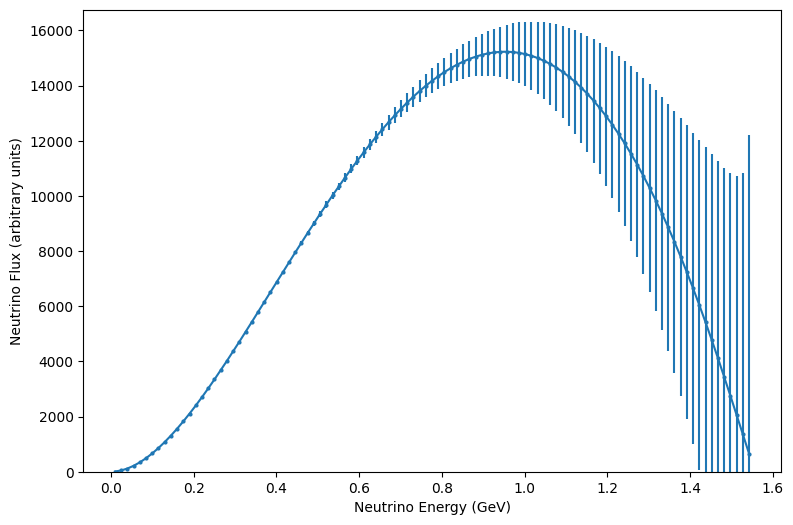

In [56]:
nuESpec = np.linspace(0.01,3,200, endpoint=True) # GeV
fluxSpec0 = np.array([neutrinoSpectrum(np.array([1.1,0.1]), np.array([eng,0]), 8) for eng in nuESpec])
plt.figure(figsize=(9,6))
plt.errorbar(nuESpec, fluxSpec0[:,0], yerr=fluxSpec0[:,1], fmt='o-', markersize=2)
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Neutrino Flux (arbitrary units)")
plt.ylim(0,max(fluxSpec0[:,0])*1.1)
plt.show()

In [57]:
flux_nue_temp = np.loadtxt('flux_nue.csv', delimiter=',')
flux_numu_temp = np.loadtxt('flux_numu.csv', delimiter=',')
prismAreas = np.loadtxt('areas.csv', delimiter=',')
flux_nue = np.zeros((8,16))
flux_numu = np.zeros((8,16))
for i in range(8):
    for j in range(16):
        flux_nue[i,j] = flux_nue_temp[i*16 + j]
        flux_numu[i,j] = flux_numu_temp[i*16 + j]
print(flux_nue)

[[0.145    0.198    0.167    0.127    0.094    0.0671   0.0539   0.0362
  0.0284   0.0228   0.0145   0.00992  0.0074   0.00493  0.00252  0.00152 ]
 [0.152    0.196    0.163    0.127    0.0943   0.0721   0.0551   0.0389
  0.0264   0.0219   0.0132   0.0104   0.00717  0.00463  0.00336  0.00201 ]
 [0.158    0.193    0.162    0.122    0.0929   0.0698   0.0504   0.0373
  0.0271   0.0197   0.0133   0.0102   0.00697  0.00404  0.00282  0.00181 ]
 [0.175    0.191    0.16     0.122    0.0924   0.0655   0.0489   0.0349
  0.0265   0.0187   0.0129   0.00915  0.00587  0.0044   0.00261  0.00183 ]
 [0.182    0.196    0.157    0.119    0.0872   0.0625   0.0467   0.0336
  0.0235   0.018    0.0113   0.00842  0.00542  0.00408  0.00248  0.00141 ]
 [0.195    0.191    0.155    0.108    0.0801   0.0602   0.0439   0.0314
  0.022    0.0164   0.0115   0.00727  0.00527  0.00325  0.00209  0.00132 ]
 [0.161    0.164    0.128    0.0946   0.0671   0.0466   0.0348   0.0247
  0.0174   0.0134   0.00926  0.00584  0.00405 

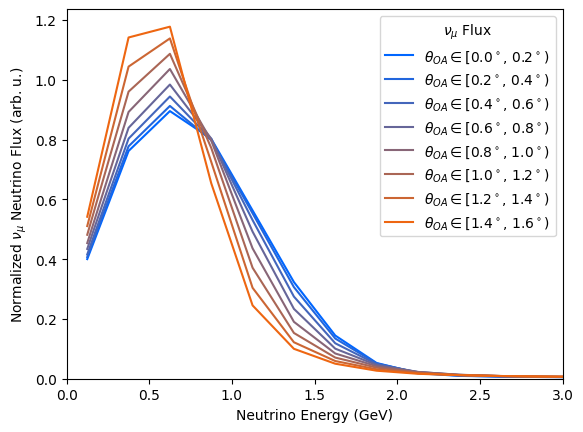

In [58]:
engs = np.linspace(0+1/8,3.75+1/8,16)
angles = np.arange(0.0,1.601,0.2)
flux_numu_norm = np.zeros(np.shape(flux_numu))
binwidth = engs[1]-engs[0]
for i in range(len(flux_numu)):
    flux_numu_norm[i,:] = flux_numu[i,:] / (sum(flux_numu[i,:])*binwidth)

plt.figure()
for i in range(len(flux_numu_norm)):
    plt.plot(engs,flux_numu_norm[i,:], color=((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255), 
             label=r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)')
plt.xlabel('Neutrino Energy (GeV)')
plt.ylabel(r'Normalized $\nu_\mu$ Neutrino Flux (arb. u.)')
plt.legend(title=r'$\nu_\mu$ Flux')
plt.xlim(0,3)
plt.ylim(0,)
plt.savefig('./figures/numuFluxNorm.png', dpi=300)

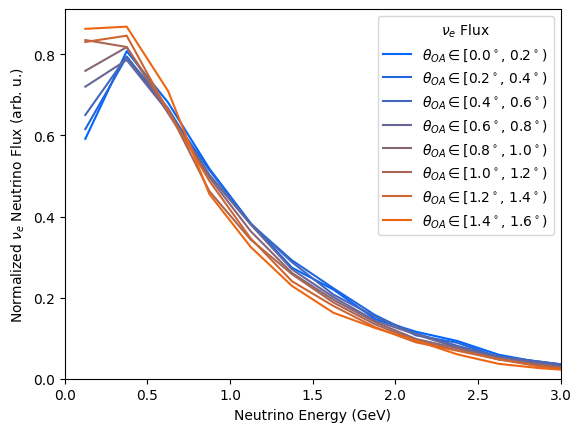

In [59]:
flux_nue_norm = np.zeros(np.shape(flux_nue))
for i in range(len(flux_nue)):
    flux_nue_norm[i,:] = flux_nue[i,:] / (sum(flux_nue[i,:])*binwidth)

plt.figure()
for i in range(len(flux_nue_norm)):
    plt.plot(engs,flux_nue_norm[i,:], color=((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255), 
             label=r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)')
plt.xlabel('Neutrino Energy (GeV)')
plt.ylabel(r'Normalized $\nu_e$ Neutrino Flux (arb. u.)')
plt.legend(title=r'$\nu_e$ Flux')
plt.xlim(0,3)
plt.ylim(0,)
plt.savefig('./figures/nueFluxNorm.png', dpi=300)

In [60]:
eFlavor = 0; muFlavor = 1; tauFlavor = 2
def tauOsc(offAxAngDex, L):
    ar1 = flux_nue[offAxAngDex,:]
    ar2 = flux_numu[offAxAngDex,:]
    angle = angles[offAxAngDex]
    L = L/np.cos(angle * (np.pi/180))
    spec = np.zeros((len(engs),2))
    engUnc = (engs[1]-engs[0])/2
    for energy in range(len(engs)):
        eVal = engs[energy]
        spec[energy,0] += ar1[energy] * oscillationProbability(eFlavor, tauFlavor, L, np.array([eVal, engUnc]))[0]
        spec[energy,0] += ar2[energy] * oscillationProbability(muFlavor, tauFlavor, L, np.array([eVal, engUnc]))[0]
        spec[energy,1] += (ar1[energy] * oscillationProbability(eFlavor, tauFlavor, L, np.array([eVal, engUnc]))[1])**2
        spec[energy,1] += (ar2[energy] * oscillationProbability(muFlavor, tauFlavor, L, np.array([eVal, engUnc]))[1])**2
    return spec

In [61]:
def nuFluxAtDistance(offAxAngleDex, flavor, L):
    """
    Calculates the neutrino spectrum (flux vs energy) at a certain distance L from the front face of SBND.

    Parameters:
    offAxAngleDex : int
        Index of which energy spectrum bin to use (0-8).
    flavor : int
        Neutrino flavor index (0: electron, 1: muon, 2: tau).
    L : [float, float]
        Distance from the front face of SBND and its uncertainty in km.
    """
    if flavor == 0:
        baseFlux = flux_nue[offAxAngleDex,:]
        otherFlux = flux_numu[offAxAngleDex,:]
        oFlav = 1
    elif flavor == 1:
        baseFlux = flux_numu[offAxAngleDex,:]
        otherFlux = flux_nue[offAxAngleDex,:]
        oFlav = 0
    elif flavor == 2:
        return tauOsc(offAxAngleDex, L)
    else:
        print("Flavor not supported.")
        return

    angle = angles[offAxAngleDex]
    L = L/np.cos(angle * (np.pi/180))
    spec = np.zeros((len(engs),2))
    engUnc = (engs[1]-engs[0])/2
    for energy in range(len(engs)):
        eVal = engs[energy]
        spec[energy,0] += baseFlux[energy] * oscillationProbability(flavor, flavor, L, np.array([eVal, engUnc]))[0]
        spec[energy,0] += otherFlux[energy] * oscillationProbability(oFlav, flavor, L, np.array([eVal, engUnc]))[0]
        spec[energy,1] += (baseFlux[energy] * oscillationProbability(flavor, flavor, L, np.array([eVal, engUnc]))[1])**2
        spec[energy,1] += (otherFlux[energy] * oscillationProbability(oFlav, flavor, L, np.array([eVal, engUnc]))[1])**2
    return spec

In [62]:
SBND_z = 0.110 # km
icarus_z = 1300 # km
dist = np.array([icarus_z - SBND_z, 0.001]) # km
icarus_nue_flux = nuFluxAtDistance(0, eFlavor, dist)
print(icarus_nue_flux)

[[6.61850356e+00 1.19126123e+04]
 [3.40483101e+00 8.61751653e+01]
 [1.48235811e+00 1.70608228e+01]
 [2.16534038e+00 6.17904995e-01]
 [8.13820064e-01 4.60119150e-01]
 [7.38177419e-02 2.52495421e-03]
 [1.07852102e-01 4.37679625e-03]
 [9.37096190e-02 5.22234989e-04]
 [5.78316100e-02 2.63951088e-05]
 [4.03566623e-02 1.63018362e-06]
 [2.89583679e-02 7.09524217e-08]
 [2.17253293e-02 8.10598400e-08]
 [1.76625858e-02 1.95771136e-07]
 [1.39485069e-02 2.53770688e-07]
 [9.48412143e-03 2.00882815e-07]
 [6.70387495e-03 1.34411040e-07]]


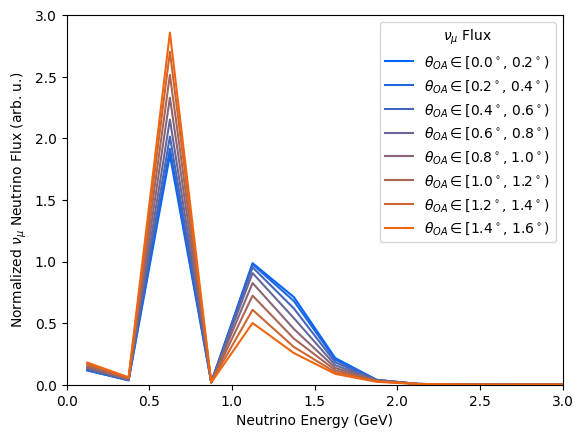

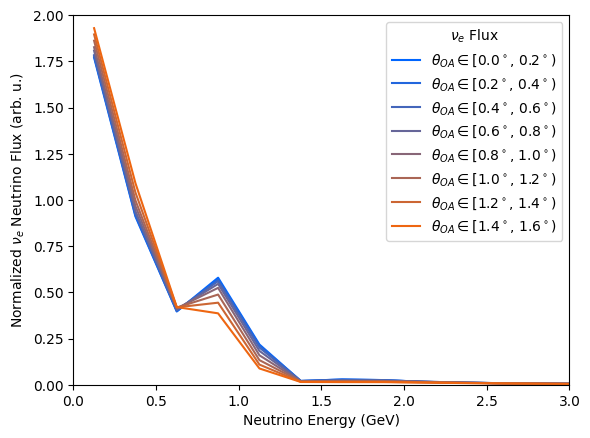

In [63]:
def normFlux(flux):
    normedFlux = np.zeros(np.shape(flux))
    for i in range(len(flux)):
        normedFlux[i,:] = flux[i,:] / (sum(flux[:,0])*binwidth)
    return normedFlux

plt.figure()
for i in range(len(flux_numu_norm)):
    icarus_numu_norm = normFlux(nuFluxAtDistance(i, muFlavor, dist))
    plt.plot(engs, icarus_numu_norm[:,0], color=((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255), 
             label=r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)')
plt.xlabel('Neutrino Energy (GeV)')
plt.ylabel(r'Normalized $\nu_\mu$ Neutrino Flux (arb. u.)')
plt.legend(title=r'$\nu_\mu$ Flux')
plt.xlim(0,3)
plt.ylim(0,3)
plt.show()

plt.figure()
for i in range(len(flux_numu_norm)):
    icarus_nue_norm = normFlux(nuFluxAtDistance(i, eFlavor, dist))
    plt.plot(engs, icarus_nue_norm[:,0], color=((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255), 
             label=r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)')
plt.xlabel('Neutrino Energy (GeV)')
plt.ylabel(r'Normalized $\nu_e$ Neutrino Flux (arb. u.)')
plt.legend(title=r'$\nu_e$ Flux')
plt.xlim(0,3)
plt.ylim(0,2)
plt.show()

In [64]:
import matplotlib.animation as ani
from IPython.display import HTML

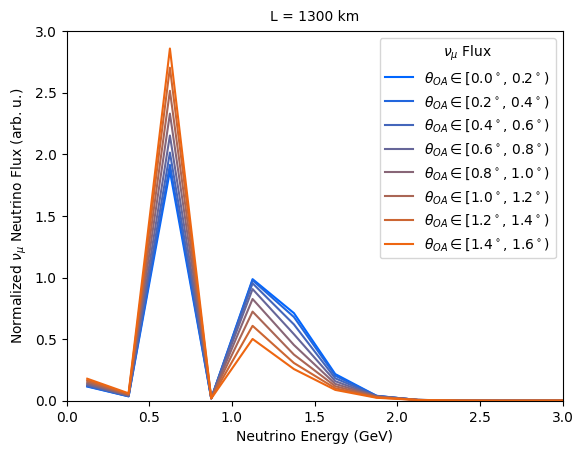

In [65]:
fig, ax = plt.subplots()
ims = []
for j in range(261):
    artists = []
    Lkm = j*5
    title = ax.text(0.5, 1.02, f'L = {Lkm} km', transform=ax.transAxes,
                    ha='center', va='bottom', animated=True)
    artists.append(title)
    for i in range(len(flux_numu_norm)):
        icarus_numu_norm = normFlux(nuFluxAtDistance(i, muFlavor, np.array([Lkm, 0.001])))
        color = ((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255)
        # plot as an animated artist
        line, = ax.plot(engs, icarus_numu_norm[:,0], color=color, animated=True)
        artists.append(line)
    if j == 0:
        ax.set_xlabel('Neutrino Energy (GeV)')
        ax.set_ylabel(r'Normalized $\nu_\mu$ Neutrino Flux (arb. u.)')
        ax.set_xlim(0,3)
        ax.set_ylim(0,3)
        # create legend once and include it in the first frame's artists
        ax.legend([r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)' for i in range(len(flux_numu_norm))],
                    title=r'$\nu_\mu$ Flux', loc='upper right')
    ims.append(artists)

am = ani.ArtistAnimation(fig, ims, interval=100, blit=True, repeat_delay=1000)
HTML(am.to_jshtml())
am.save(filename='./figures/numuFluxEvolution.gif', writer='pillow', dpi=300)

Animation size has reached 21018192 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


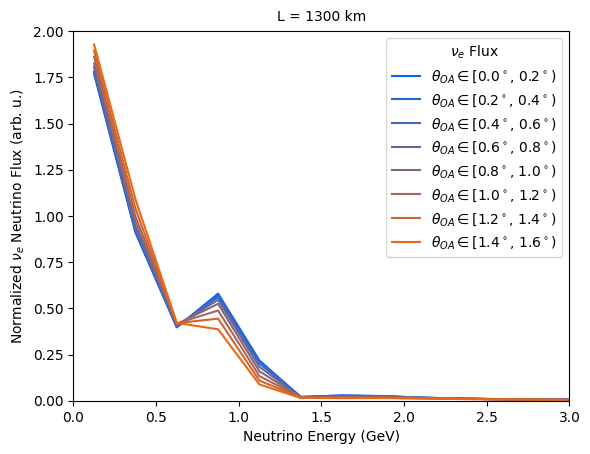

In [66]:
fig, ax = plt.subplots()
ims = []
for j in range(261):
    artists = []
    Lkm = j*5
    title = ax.text(0.5, 1.02, f'L = {Lkm} km', transform=ax.transAxes,
                    ha='center', va='bottom', animated=True)
    artists.append(title)
    for i in range(len(flux_nue_norm)):
        icarus_nue_norm = normFlux(nuFluxAtDistance(i, eFlavor, np.array([Lkm, 0.001])))
        color = ((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255)
        # plot as an animated artist
        line, = ax.plot(engs, icarus_nue_norm[:,0], color=color, animated=True)
        artists.append(line)
    if j == 0:
        ax.set_xlabel('Neutrino Energy (GeV)')
        ax.set_ylabel(r'Normalized $\nu_e$ Neutrino Flux (arb. u.)')
        ax.set_xlim(0,3)
        ax.set_ylim(0,2)
        # create legend once and include it in the first frame's artists
        ax.legend([r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)' for i in range(len(flux_nue_norm))],
                    title=r'$\nu_e$ Flux', loc='upper right')
    ims.append(artists)

am = ani.ArtistAnimation(fig, ims, interval=100, blit=True, repeat_delay=1000)
HTML(am.to_jshtml())
am.save(filename='./figures/nueFluxEvolution.gif', writer='pillow', dpi=300)

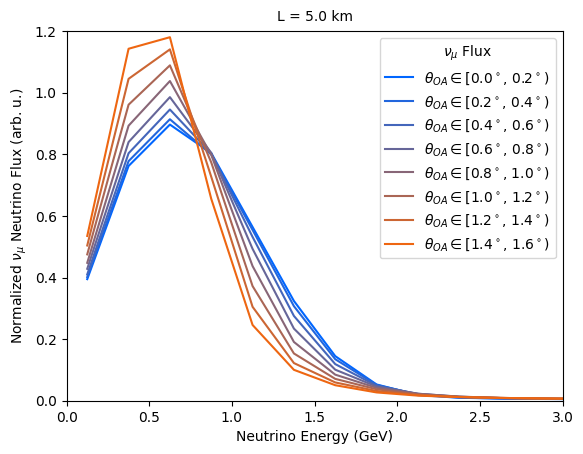

In [67]:
fig, ax = plt.subplots()
ims = []
for j in range(101):
    artists = []
    Lkm = round(j*5e-2,2)
    title = ax.text(0.5, 1.02, f'L = {Lkm} km', transform=ax.transAxes,
                    ha='center', va='bottom', animated=True)
    artists.append(title)
    for i in range(len(flux_numu_norm)):
        icarus_numu_norm = normFlux(nuFluxAtDistance(i, muFlavor, np.array([Lkm, 0.001])))
        color = ((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255)
        # plot as an animated artist
        line, = ax.plot(engs, icarus_numu_norm[:,0], color=color, animated=True)
        artists.append(line)
    if j == 0:
        ax.set_xlabel('Neutrino Energy (GeV)')
        ax.set_ylabel(r'Normalized $\nu_\mu$ Neutrino Flux (arb. u.)')
        ax.set_xlim(0,3)
        ax.set_ylim(0,1.2)
        # create legend once and include it in the first frame's artists
        ax.legend([r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)' for i in range(len(flux_numu_norm))],
                    title=r'$\nu_\mu$ Flux', loc='upper right')
    ims.append(artists)

am = ani.ArtistAnimation(fig, ims, interval=100, blit=True, repeat_delay=1000)
HTML(am.to_jshtml())
am.save(filename='./figures/numuFluxRatioEvolutionShort.gif', writer='pillow', dpi=300)

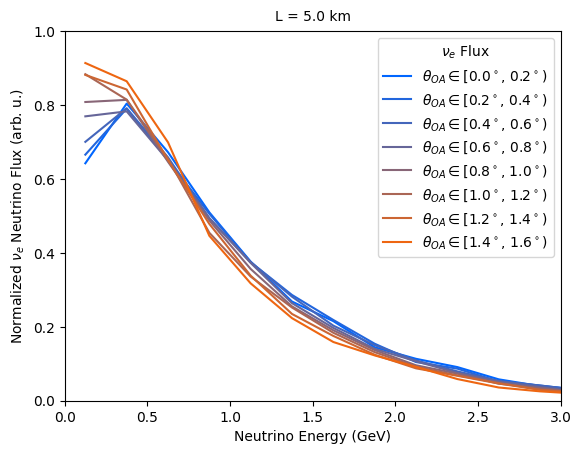

In [68]:
fig, ax = plt.subplots()
ims = []
for j in range(101):
    artists = []
    Lkm = round(j*5e-2,2)
    title = ax.text(0.5, 1.02, f'L = {Lkm} km', transform=ax.transAxes,
                    ha='center', va='bottom', animated=True)
    artists.append(title)
    for i in range(len(flux_nue_norm)):
        icarus_nue_norm = normFlux(nuFluxAtDistance(i, eFlavor, np.array([Lkm, 0.001])))
        color = ((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255)
        # plot as an animated artist
        line, = ax.plot(engs, icarus_nue_norm[:,0], color=color, animated=True)
        artists.append(line)
    if j == 0:
        ax.set_xlabel('Neutrino Energy (GeV)')
        ax.set_ylabel(r'Normalized $\nu_e$ Neutrino Flux (arb. u.)')
        ax.set_xlim(0,3)
        ax.set_ylim(0,1)
        # create legend once and include it in the first frame's artists
        ax.legend([r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)' for i in range(len(flux_nue_norm))],
                    title=r'$\nu_e$ Flux', loc='upper right')
    ims.append(artists)

am = ani.ArtistAnimation(fig, ims, interval=100, blit=True, repeat_delay=1000)
HTML(am.to_jshtml())
am.save(filename='./figures/nueFluxRatioEvolutionShort.gif', writer='pillow', dpi=300)

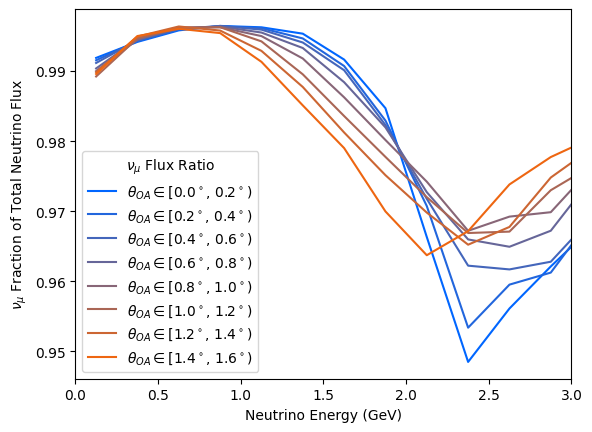

In [69]:
ratio = np.zeros(np.shape(flux_nue))
for i in range(len(flux_nue)):
    for j in range(len(flux_nue[0])):
        if flux_numu[i,j] != 0:
            ratio[i,j] = flux_numu[i,j] / (flux_nue[i,j]+flux_numu[i,j])

plt.figure()
for i in range(len(ratio)):
    plt.plot(engs, ratio[i,:], color=((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255), 
             label=r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)')
plt.xlabel('Neutrino Energy (GeV)')
plt.ylabel(r'$\nu_\mu$ Fraction of Total Neutrino Flux')
plt.legend(title=r'$\nu_\mu$ Flux Ratio')
plt.xlim(0,3)
plt.savefig('./figures/numuFluxRatio.png', dpi=300)

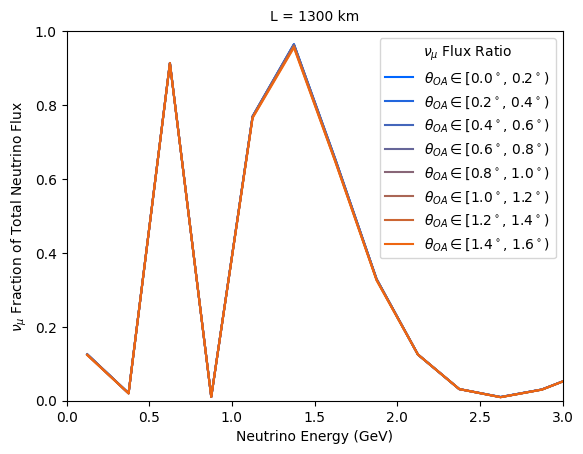

In [70]:
fig, ax = plt.subplots()
ims = []
for j in range(261):
    artists = []
    Lkm = j*5
    title = ax.text(0.5, 1.02, f'L = {Lkm} km', transform=ax.transAxes,
                    ha='center', va='bottom', animated=True)
    artists.append(title)
    for i in range(len(flux_numu_norm)):
        numu = nuFluxAtDistance(i, muFlavor, np.array([Lkm, 0.001]))
        nue = nuFluxAtDistance(i, eFlavor, np.array([Lkm, 0.001]))
        color = ((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255)
        nutau = nuFluxAtDistance(i, tauFlavor, np.array([Lkm, 0.001]))
        ratio = np.divide(numu[:,0], numu[:,0] + nue[:,0] + nutau[:,0])
        line, = ax.plot(engs, ratio, color=color, animated=True)
        artists.append(line)
    if j == 0:
        ax.set_xlabel('Neutrino Energy (GeV)')
        ax.set_ylabel(r'$\nu_\mu$ Fraction of Total Neutrino Flux')
        ax.set_xlim(0,3)
        ax.set_ylim(0,1)
        # create legend once and include it in the first frame's artists
        ax.legend([r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)' for i in range(len(flux_numu_norm))],
                    title=r'$\nu_\mu$ Flux Ratio', loc='upper right')
    ims.append(artists)

am = ani.ArtistAnimation(fig, ims, interval=100, blit=True, repeat_delay=1000)
HTML(am.to_jshtml())
am.save(filename='./figures/numuFluxRatioEvolution.gif', writer='pillow', dpi=300)

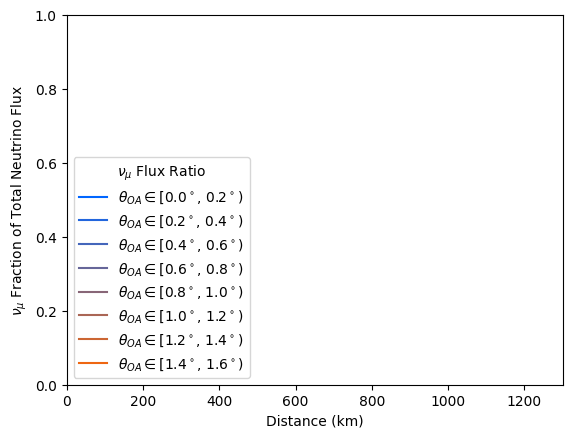

In [71]:
dists = np.arange(0,1301,5)
#dists = np.arange(0,5,.1)
asEng = np.zeros((len(engs), len(flux_numu), len(dists)))
for i in range(len(flux_numu)):
    for j in range(len(dists)):
        Lkm = dists[j]
        numu = nuFluxAtDistance(i, muFlavor, np.array([Lkm, 0.001]))
        nue = nuFluxAtDistance(i, eFlavor, np.array([Lkm, 0.001]))
        nutau = nuFluxAtDistance(i, tauFlavor, np.array([Lkm, 0.001]))
        ratio = np.divide(numu[:,0], numu[:,0] + nue[:,0] + nutau[:,0])
        asEng[:,i,j] = ratio

fig, ax = plt.subplots()
ims = []
for j in range(len(engs)):
    artists = []
    title = ax.text(0.5, 1.02, f'E = {engs[j]} GeV', transform=ax.transAxes,
                    ha='center', va='bottom', animated=True)
    artists.append(title)
    for i in range(len(flux_numu)):
        color = ((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255)
        line, = ax.plot(dists, asEng[j,i,:], color=color, animated=True)
        artists.append(line)
    if j == 0:
        ax.set_xlabel('Distance (km)')
        ax.set_ylabel(r'$\nu_\mu$ Fraction of Total Neutrino Flux')
        ax.set_xlim(0,max(dists))
        ax.set_ylim(0,1)
        # create legend once and include it in the first frame's artists
        ax.legend([r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)' for i in range(len(flux_numu_norm))],
                    title=r'$\nu_\mu$ Flux Ratio', loc='lower left')
    ims.append(artists)

am = ani.ArtistAnimation(fig, ims, interval=500, repeat_delay=1000)
HTML(am.to_jshtml())
am.save(filename='./figures/numuFluxRatioDistEvolution.gif', writer='pillow', dpi=300)

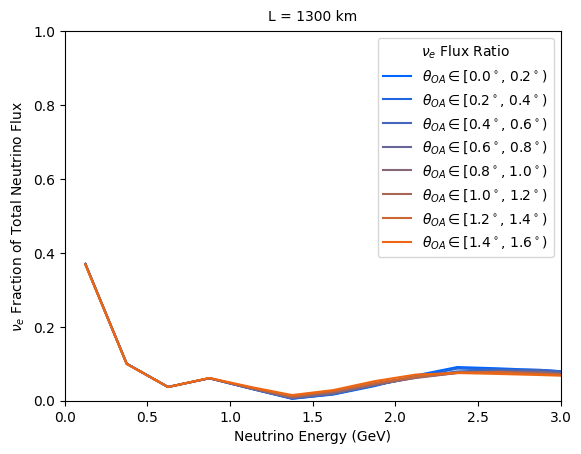

In [72]:
fig, ax = plt.subplots()
ims = []
for j in range(261):
    artists = []
    Lkm = j*5
    title = ax.text(0.5, 1.02, f'L = {Lkm} km', transform=ax.transAxes,
                    ha='center', va='bottom', animated=True)
    artists.append(title)
    for i in range(len(flux_nue_norm)):
        numu = nuFluxAtDistance(i, muFlavor, np.array([Lkm, 0.001]))
        nue = nuFluxAtDistance(i, eFlavor, np.array([Lkm, 0.001]))
        color = ((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255)
        nutau = nuFluxAtDistance(i, tauFlavor, np.array([Lkm, 0.001]))
        ratio = np.divide(nue[:,0], numu[:,0] + nue[:,0] + nutau[:,0])
        line, = ax.plot(engs, ratio, color=color, animated=True)
        artists.append(line)
    if j == 0:
        ax.set_xlabel('Neutrino Energy (GeV)')
        ax.set_ylabel(r'$\nu_e$ Fraction of Total Neutrino Flux')
        ax.set_xlim(0,3)
        ax.set_ylim(0,1)
        # create legend once and include it in the first frame's artists
        ax.legend([r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)' for i in range(len(flux_numu_norm))],
                    title=r'$\nu_e$ Flux Ratio', loc='upper right')
    ims.append(artists)

am = ani.ArtistAnimation(fig, ims, interval=100, blit=True, repeat_delay=1000)
HTML(am.to_jshtml())
am.save(filename='./figures/nueFluxRatioEvolution.gif', writer='pillow', dpi=300)

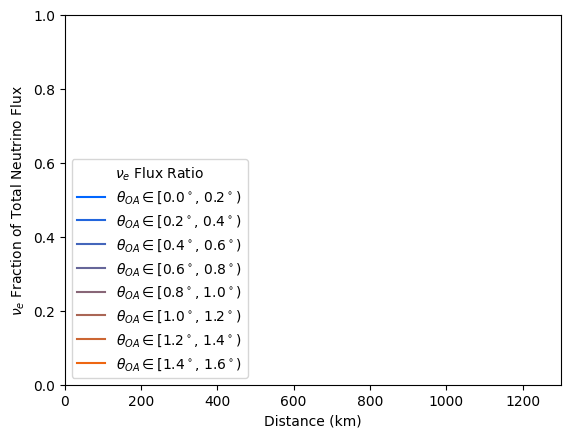

In [73]:
dists = np.arange(0,1301,5)
#dists = np.arange(0,5,.1)
asEng = np.zeros((len(engs), len(flux_nue), len(dists)))
for i in range(len(flux_nue)):
    for j in range(len(dists)):
        Lkm = dists[j]
        numu = nuFluxAtDistance(i, muFlavor, np.array([Lkm, 0.001]))
        nue = nuFluxAtDistance(i, eFlavor, np.array([Lkm, 0.001]))
        nutau = nuFluxAtDistance(i, tauFlavor, np.array([Lkm, 0.001]))
        ratio = np.divide(nue[:,0], numu[:,0] + nue[:,0] + nutau[:,0])
        asEng[:,i,j] = ratio

fig, ax = plt.subplots()
ims = []
for j in range(len(engs)):
    artists = []
    title = ax.text(0.5, 1.02, f'E = {engs[j]} GeV', transform=ax.transAxes,
                    ha='center', va='bottom', animated=True)
    artists.append(title)
    for i in range(len(flux_nue)):
        color = ((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255)
        line, = ax.plot(dists, asEng[j,i,:], color=color, animated=True)
        artists.append(line)
    if j == 0:
        ax.set_xlabel('Distance (km)')
        ax.set_ylabel(r'$\nu_e$ Fraction of Total Neutrino Flux')
        ax.set_xlim(0,max(dists))
        ax.set_ylim(0,1)
        # create legend once and include it in the first frame's artists
        ax.legend([r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)' for i in range(len(flux_numu_norm))],
                    title=r'$\nu_e$ Flux Ratio', loc='lower left')
    ims.append(artists)

am = ani.ArtistAnimation(fig, ims, interval=500, repeat_delay=1000)
HTML(am.to_jshtml())
am.save(filename='./figures/nueFluxRatioDistEvolution.gif', writer='pillow', dpi=300)

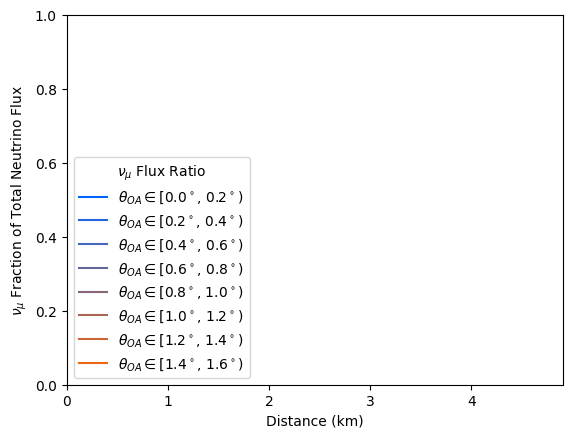

In [74]:
#dists = np.arange(0,1301,5)
dists = np.arange(0,5,.1)
asEng = np.zeros((len(engs), len(flux_numu), len(dists)))
for i in range(len(flux_numu)):
    for j in range(len(dists)):
        Lkm = dists[j]
        numu = nuFluxAtDistance(i, muFlavor, np.array([Lkm, 0.001]))
        nue = nuFluxAtDistance(i, eFlavor, np.array([Lkm, 0.001]))
        nutau = nuFluxAtDistance(i, tauFlavor, np.array([Lkm, 0.001]))
        ratio = np.divide(numu[:,0], numu[:,0] + nue[:,0] + nutau[:,0])
        asEng[:,i,j] = ratio

fig, ax = plt.subplots()
ims = []
for j in range(len(engs)):
    artists = []
    title = ax.text(0.5, 1.02, f'E = {engs[j]} GeV', transform=ax.transAxes,
                    ha='center', va='bottom', animated=True)
    artists.append(title)
    for i in range(len(flux_numu)):
        color = ((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255)
        line, = ax.plot(dists, asEng[j,i,:], color=color, animated=True)
        artists.append(line)
    if j == 0:
        ax.set_xlabel('Distance (km)')
        ax.set_ylabel(r'$\nu_\mu$ Fraction of Total Neutrino Flux')
        ax.set_xlim(0,max(dists))
        ax.set_ylim(0,1)
        # create legend once and include it in the first frame's artists
        ax.legend([r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)' for i in range(len(flux_numu_norm))],
                    title=r'$\nu_\mu$ Flux Ratio', loc='lower left')
    ims.append(artists)

am = ani.ArtistAnimation(fig, ims, interval=500, repeat_delay=1000)
HTML(am.to_jshtml())
am.save(filename='./figures/numuFluxRatioDistEvolutionShort.gif', writer='pillow', dpi=300)

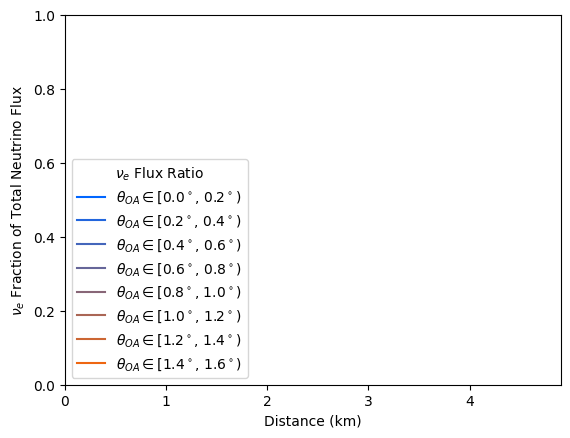

In [75]:
#dists = np.arange(0,1301,5)
dists = np.arange(0,5,.1)
asEng = np.zeros((len(engs), len(flux_nue), len(dists)))
for i in range(len(flux_nue)):
    for j in range(len(dists)):
        Lkm = dists[j]
        numu = nuFluxAtDistance(i, muFlavor, np.array([Lkm, 0.001]))
        nue = nuFluxAtDistance(i, eFlavor, np.array([Lkm, 0.001]))
        nutau = nuFluxAtDistance(i, tauFlavor, np.array([Lkm, 0.001]))
        ratio = np.divide(nue[:,0], numu[:,0] + nue[:,0] + nutau[:,0])
        asEng[:,i,j] = ratio

fig, ax = plt.subplots()
ims = []
for j in range(len(engs)):
    artists = []
    title = ax.text(0.5, 1.02, f'E = {engs[j]} GeV', transform=ax.transAxes,
                    ha='center', va='bottom', animated=True)
    artists.append(title)
    for i in range(len(flux_nue)):
        color = ((2*i*16+2*i)/255, .4, (((15-2*i)*16+15-2*i))/255)
        line, = ax.plot(dists, asEng[j,i,:], color=color, animated=True)
        artists.append(line)
    if j == 0:
        ax.set_xlabel('Distance (km)')
        ax.set_ylabel(r'$\nu_e$ Fraction of Total Neutrino Flux')
        ax.set_xlim(0,max(dists))
        ax.set_ylim(0,1)
        # create legend once and include it in the first frame's artists
        ax.legend([r'$\theta_{OA}\in$['+str(round(angles[i],2))+'$^\circ$, '+str(round(angles[i+1],2))+'$^\circ$)' for i in range(len(flux_numu_norm))],
                    title=r'$\nu_e$ Flux Ratio', loc='lower left')
    ims.append(artists)

am = ani.ArtistAnimation(fig, ims, interval=500, repeat_delay=1000)
HTML(am.to_jshtml())
am.save(filename='./figures/nueFluxRatioDistEvolutionShort.gif', writer='pillow', dpi=300)